# VoxSight Recall — last-seen is not where it is

*Companion to `problem_statement.md`. Paper context: `A_Literature_Roadmap_for_VoxSight_Recall.pdf`.*

An episodic visual-memory assistant is asked **"where are my keys?"** Every system in this lineage —
Ego4D episodic memory, MemPal, the long-video memory models — answers *where was it last seen*. The
user asked *where is it now*. This notebook measures how far apart those two are, and what it costs
to close the gap.

The four hypotheses under test (full statements in `problem_statement.md` §5):

| | Claim |
|---|---|
| **H1** | Last-occurrence retrieval scores well on Recall@K while being wrong about the present. |
| **H2** | MemoryBank's Ebbinghaus decay is on the wrong axis — it should govern confidence, not retention. |
| **H3** | Interaction-triggered capture keeps placement recall at a fraction of uniform sampling's frames. |
| **H4** | The number that matters for safety is the *confidently-wrong* rate, not accuracy. |

Run from this directory (`papers/LLVM/VoxSight/`); all paths are relative to it.

## 0. Config

In [1]:
import os, ast, json, math, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Do not set the high ratio to 0.0 -- that removes the allocation ceiling and an
# over-allocation then swaps the machine instead of raising a catchable error (../README.md).
# Both must be set together, low < high: the defaults are low 1.4 / high 1.7, so setting
# only the high ratio to 0.8 leaves it *below* the low watermark and every .to("mps")
# raises "invalid low watermark ratio 1.4".
os.environ.setdefault("PYTORCH_MPS_LOW_WATERMARK_RATIO", "0.7")
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.8")

SEED = 0
random.seed(SEED); np.random.seed(SEED)

ROOT     = Path(".").resolve()
ANN      = ROOT / "annotations"       # cloned epic-kitchens-100-annotations (gitignored)
DATA     = ROOT / "data"              # rgb_frames tars, extracted           (gitignored)
FEATURES = ROOT / "features"          # cached backbone features             (gitignored)
CKPT     = ROOT / "checkpoints"       # trained heads                        (gitignored)
RESULTS  = ROOT / "results"
for d in (FEATURES, CKPT, RESULTS): d.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False})

print("root:", ROOT)
print("annotations present:", (ANN / "EPIC_100_train.csv").exists())

root: /Users/atharvax/dev/til/papers/LLVM/VoxSight
annotations present: True


## 1. Events and queries from narrations

EPIC-KITCHENS-100's narration annotations already encode object state transitions, which is what
makes this study possible without hand-labelling. Two verb groups matter:

- **PUT** — verb classes `put`(1) and `insert`(5). `all_nouns` holds the object *and* the receptacle:
  `"put tablecloth into cupboard"` → `['tablecloth', 'cupboard']`. This is the only kind of event
  that can ground a location answer.
- **TAKE** — verb classes `take`(0), `remove`(12), `move`(11). Grounds nothing, but **invalidates**
  the standing answer. This is negative evidence, and the claim of this notebook is that dropping it
  is what makes these systems unsafe.

Note the asymmetry up front: only about a third of PUTs name a receptacle. A bare `"put down plate"`
tells us the object moved but not where to — a third state, `PLACED_UNKNOWN`, which an honest system
must be able to express.

In [2]:
PUT_VERBS  = {1, 5}       # put, insert
TAKE_VERBS = {0, 12, 11}  # take, remove, move

def load_annotations():
    tr = pd.read_csv(ANN / "EPIC_100_train.csv")
    va = pd.read_csv(ANN / "EPIC_100_validation.csv")
    tr["epic_split"], va["epic_split"] = "train", "val"
    df = pd.concat([tr, va], ignore_index=True)
    df["all_noun_classes"] = df["all_noun_classes"].apply(ast.literal_eval)
    df["all_nouns"] = df["all_nouns"].apply(ast.literal_eval)
    return df

def noun_names():
    n = pd.read_csv(ANN / "EPIC_100_noun_classes.csv")
    return dict(zip(n.id, n.key))

ann   = load_annotations()
NOUN  = noun_names()
print(f"narration rows {len(ann):,} | videos {ann.video_id.nunique()} | "
      f"participants {ann.participant_id.nunique()}")

narration rows 76,885 | videos 633 | participants 34


In [3]:
def to_events(df):
    '''One narration row -> one state event, or nothing.

    receptacle = the first noun in `all_nouns` that is not the object itself.
    NaN (not None) marks 'no receptacle named' -- the column is float once it has gaps,
    so every downstream check must use pd.isna, never `is None`.
    '''
    rows = []
    for r in df.itertuples():
        if   r.verb_class in PUT_VERBS:  kind = "PUT"
        elif r.verb_class in TAKE_VERBS: kind = "TAKE"
        else: continue
        recep = next((nc for nc in r.all_noun_classes if nc != r.noun_class), None)
        rows.append((r.video_id, r.participant_id, r.start_frame, r.stop_frame,
                     kind, r.noun_class, recep, r.narration))
    ev = pd.DataFrame(rows, columns=["video_id", "participant_id", "start_frame",
                                     "stop_frame", "kind", "obj", "recep", "narration"])
    return ev.sort_values(["video_id", "start_frame"]).reset_index(drop=True)

events = to_events(ann)
n_put  = (events.kind == "PUT").sum()
print(f"state events {len(events):,}")
print(events.kind.value_counts().to_string())
print(f"\nPUTs naming a receptacle: {events[events.kind=='PUT'].recep.notna().sum():,} / {n_put:,} "
      f"({events[events.kind=='PUT'].recep.notna().mean():.1%})")

state events 37,424
kind
TAKE    19866
PUT     17558

PUTs naming a receptacle: 5,423 / 17,558 (30.9%)


### 1.2 The state machine

Per object, walk the event stream and track two things that a last-occurrence system conflates:

- `last_put[obj]` — the most recent receptacle-bearing PUT. **This is the answer S0 gives**, forever,
  until a newer PUT overwrites it.
- `state[obj]` — what is actually true now: `AT(r)`, `GONE` (taken since), or `PLACED_UNKNOWN`
  (put down since, receptacle unobserved).

A query is emitted after every event, for every object whose location has ever been asserted. The
baseline is *stale* whenever `state` is not `AT(last_put.recep)`.

In [4]:
def build_queries(events):
    out = []
    for vid, g in events.groupby("video_id", sort=False):
        state, last_put = {}, {}
        for e in g.itertuples():
            # --- apply the event ---
            if e.kind == "PUT":
                if not pd.isna(e.recep):
                    state[e.obj] = ("AT", e.recep)
                    last_put[e.obj] = (e.recep, e.start_frame)
                else:
                    state[e.obj] = ("PLACED_UNKNOWN", None)
            else:
                state[e.obj] = ("GONE", None)

            # --- query every object the system could answer about ---
            for obj, (recep, put_frame) in last_put.items():
                if obj == e.obj and put_frame == e.start_frame:
                    continue                      # don't query the event just written
                st, gt_recep = state[obj]
                out.append({
                    "video_id": vid, "participant_id": e.participant_id,
                    "query_frame": e.start_frame, "obj": obj,
                    "s0_recep": recep, "s0_frame": put_frame,
                    "gt_state": st, "gt_recep": gt_recep,
                    "s0_correct": (st == "AT" and gt_recep == recep),
                    "age_frames": e.start_frame - put_frame,
                })
    return pd.DataFrame(out)

queries = build_queries(events)
print(f"queries {len(queries):,} over {queries.video_id.nunique()} videos")

queries 173,624 over 451 videos


### 1.3 Verification — is the ground truth actually right?

The GT rule is the foundation of every number below, so it gets checked before it gets used. Three
checks: an internal consistency assertion, a mechanical replay of one video against its raw
narrations, and a printed sample to read by eye.

In [5]:
# (a) internal consistency: s0_correct must be exactly 'state is AT and receptacle matches'
chk = queries.s0_correct == ((queries.gt_state == "AT") & (queries.gt_recep == queries.s0_recep))
assert chk.all(), "s0_correct disagrees with its own definition"

# (b) independent replay of one video, recomputing GT from raw narrations
def replay_check(vid, n=400):
    ev = events[events.video_id == vid]
    q  = queries[queries.video_id == vid].head(n)
    bad = 0
    for r in q.itertuples():
        after = ev[(ev.start_frame > r.s0_frame) & (ev.start_frame <= r.query_frame)
                   & (ev.obj == r.obj)]
        # object is still where S0 says iff nothing touched it since that PUT
        truth = len(after) == 0
        if truth != r.s0_correct: bad += 1
    return bad, len(q)

for vid in ["P04_113", "P30_107"]:
    bad, tot = replay_check(vid)
    print(f"replay {vid}: {bad}/{tot} mismatches")
assert replay_check("P04_113")[0] == 0

# (c) eyeball a sample
s = queries[queries.video_id == "P04_113"].sample(8, random_state=SEED)
for r in s.itertuples():
    ans = f"{NOUN[r.obj]} is on/in the {NOUN[r.s0_recep]}"
    gt  = f"AT {NOUN[r.gt_recep]}" if r.gt_state == "AT" else r.gt_state
    print(f"f{r.query_frame:>7}  S0 says: {ans:<38} | truth: {gt:<22} "
          f"| {'ok' if r.s0_correct else 'STALE'}")

replay P04_113: 0/400 mismatches
replay P30_107: 0/400 mismatches
f  47727  S0 says: towel is on/in the oven                | truth: AT oven                | ok
f  47040  S0 says: presser is on/in the drawer            | truth: AT drawer              | ok
f  44595  S0 says: pin:rolling is on/in the dishwasher    | truth: AT dishwasher          | ok
f  41000  S0 says: scissors is on/in the tray             | truth: AT tray                | ok
f  38611  S0 says: presser is on/in the drawer            | truth: AT drawer              | ok
f  13778  S0 says: presser is on/in the drawer            | truth: AT drawer              | ok
f  23720  S0 says: bowl is on/in the cooker:slow          | truth: AT cooker:slow         | ok
f  40509  S0 says: spatula is on/in the dishwasher        | truth: GONE                   | STALE


## 2. H1 — how often is the last-seen answer already wrong?

This is the go/no-go for the whole project, and it costs no video and no GPU: if staleness is rare,
H1 is dead and nothing downstream is worth building.

In [6]:
stale = 1 - queries.s0_correct.mean()
print(f"queries              {len(queries):,}")
print(f"S0 (last-occurrence) correct : {queries.s0_correct.mean():6.1%}")
print(f"S0 STALE                     : {stale:6.1%}   <-- H1")
print("\nground-truth state at query time:")
for k, v in queries.gt_state.value_counts(normalize=True).items():
    print(f"  {k:<16} {v:6.1%}")

print("\nRetrieval vs answer, oracle perception:")
print(f"  Recall@1 of the grounding event : 100.0%   (object identity is exact)")
print(f"  current-location accuracy       : {queries.s0_correct.mean():6.1%}")
print(f"  ---> gap unmeasured by Recall@K : {stale:6.1%}")

queries              173,624
S0 (last-occurrence) correct :  69.1%
S0 STALE                     :  30.9%   <-- H1

ground-truth state at query time:
  AT                69.1%
  GONE              16.2%
  PLACED_UNKNOWN    14.6%

Retrieval vs answer, oracle perception:
  Recall@1 of the grounding event : 100.0%   (object identity is exact)
  current-location accuracy       :  69.1%
  ---> gap unmeasured by Recall@K :  30.9%


That gap is the whole point. With oracle perception the retriever is *perfect* — it always finds the
right past event, because object identity is exact and there is no embedding to get wrong. Recall@1
is 100%. And the answer built on that perfect retrieval is wrong about the present roughly a third
of the time.

No amount of better retrieval fixes this. The information needed is not in the retrieved event.

            stale      n
age_bin                 
<5s      0.236730   3523
5-30s    0.159517  14149
30s-2m   0.210677  33193
2-10m    0.316805  73670
>10m     0.410781  49087


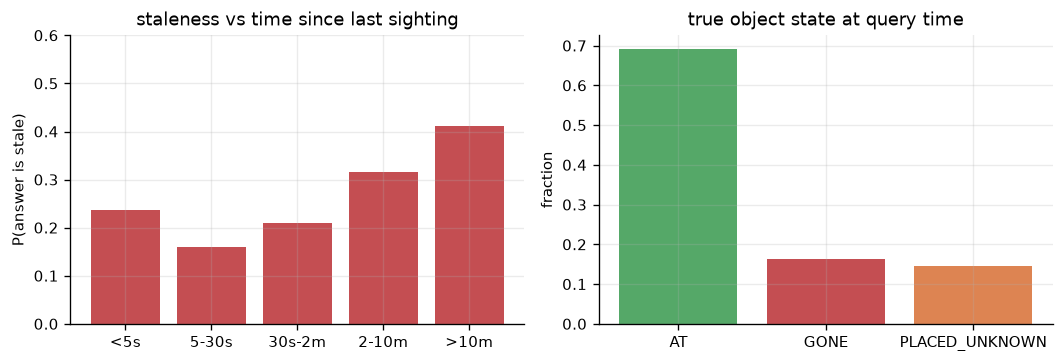

In [7]:
FPS_NOM = 50  # EPIC extension videos; used only for readable axis labels
q = queries.copy()
q["age_s"] = q.age_frames / FPS_NOM

bins   = [0, 5, 30, 120, 600, 10**9]
labels = ["<5s", "5-30s", "30s-2m", "2-10m", ">10m"]
q["age_bin"] = pd.cut(q.age_s, bins, labels=labels)
by_age = q.groupby("age_bin", observed=True).agg(
    stale=("s0_correct", lambda s: 1 - s.mean()), n=("s0_correct", "size"))
print(by_age.to_string())

fig, ax = plt.subplots(1, 2, figsize=(9, 3.1))
ax[0].bar(labels, by_age.stale, color="#c44e52")
ax[0].set_title("staleness vs time since last sighting"); ax[0].set_ylabel("P(answer is stale)")
ax[0].set_ylim(0, .6)
gt = queries.gt_state.value_counts(normalize=True)
ax[1].bar(gt.index, gt.values, color=["#55a868", "#c44e52", "#dd8452"])
ax[1].set_title("true object state at query time"); ax[1].set_ylabel("fraction")
fig.tight_layout(); fig.savefig(RESULTS / "h1_staleness.png", bbox_inches="tight"); plt.show()

### 2.1 First finding: time is a weak proxy for staleness

Staleness rises with age — 16% at 5–30s to 41% past ten minutes — so elapsed time *does* carry
signal. But look at the shape. Three orders of magnitude of elapsed time move the stale rate by
about 25 points, and the curve is not even monotonic: the `<5s` bucket is *worse* than `5–30s`,
because an object you just set down is an object you are about to pick back up.

A decay function of time alone can never separate the 41% of >10m answers that are wrong from the
59% that are fine. That is H2's target, and it is already visible here.

## 3. H2(b) — decay-as-confidence vs the contradiction signal

MemoryBank scores memory strength as an Ebbinghaus curve, `exp(-Δt/S)`. Ported to visual memory
that gives a confidence that decays with elapsed time. The alternative is to look for **negative
evidence**: has anything touched this object since the sighting?

**Read the second number with care.** Under oracle perception the contradiction signal is
*definitionally* the ground truth — an object is stale exactly when something touched it — so its
AUC is 1.000 by construction. That is a tautology, not a result. It is reported only to fix the
ceiling. The honest comparison needs a *noisy* contradiction signal from the trained event head, and
it happens in Stage 5.

The number that does mean something today is the first one: how well elapsed time alone predicts
staleness, on an axis that owes nothing to the construction.

In [8]:
from sklearn.metrics import roc_auc_score

y = (~queries.s0_correct).astype(int).values           # 1 = the answer is stale

# (i) MemoryBank-style: older == more likely stale
score_time = queries.age_frames.values.astype(float)

# (ii) contradiction: has any event touched this object since the grounding PUT?
#      computed the same way the replay check did, vectorised per video
touch = []
for vid, g in queries.groupby("video_id", sort=False):
    ev = events[events.video_id == vid]
    by_obj = {o: sub.start_frame.values for o, sub in ev.groupby("obj")}
    for r in g.itertuples():
        f = by_obj.get(r.obj, np.empty(0))
        touch.append(int(((f > r.s0_frame) & (f <= r.query_frame)).sum()))
queries["n_touch"] = touch
score_contra = queries.n_touch.values.astype(float)

auc_t, auc_c = roc_auc_score(y, score_time), roc_auc_score(y, score_contra)
print(f"AUC, elapsed time alone (Ebbinghaus axis) : {auc_t:.3f}   <-- meaningful")
print(f"AUC, contradiction count, ORACLE          : {auc_c:.3f}   <-- circular, ceiling only")
print(f"\nElapsed time carries {(auc_t-.5)/.5:.0%} of the way from chance to perfect.")
print("A confidence that decays on the time axis is mostly guessing about the thing")
print("the user actually needs to know.")

AUC, elapsed time alone (Ebbinghaus axis) : 0.616   <-- meaningful
AUC, contradiction count, ORACLE          : 1.000   <-- circular, ceiling only

Elapsed time carries 23% of the way from chance to perfect.
A confidence that decays on the time axis is mostly guessing about the thing
the user actually needs to know.


## 4. Split and video selection

Splits are **by participant**, never by clip — two videos from the same kitchen share objects,
receptacles and habits, and splitting on clips would leak all three. The 11 videos downloaded for
the perception stage are one or two per participant, chosen for query density.

In [9]:
VIDEOS = ["P30_107", "P30_111", "P04_113", "P04_121", "P01_105", "P02_129",
          "P03_109", "P12_101", "P06_101", "P23_102", "P11_104"]
SPLIT = {  # by participant
    "train": ["P01", "P02", "P03", "P12", "P06"],
    "val":   ["P23", "P11"],
    "test":  ["P04", "P30"],
}
P2SPLIT = {p: s for s, ps in SPLIT.items() for p in ps}

sub = queries[queries.video_id.isin(VIDEOS)].copy()
sub["split"] = sub.participant_id.map(P2SPLIT)

# leakage assertion: no participant in two splits
assert all(len(set(a) & set(b)) == 0
           for i, a in enumerate(SPLIT.values()) for b in list(SPLIT.values())[i+1:])
assert sub.split.notna().all()

print(sub.groupby("split").agg(queries=("obj", "size"),
                               videos=("video_id", "nunique"),
                               stale=("s0_correct", lambda s: 1 - s.mean())).to_string())
print(f"\nselected subset: {len(sub):,} queries, stale {1-sub.s0_correct.mean():.1%}")
sub.to_parquet(RESULTS / "queries.parquet")
events[events.video_id.isin(VIDEOS)].to_parquet(RESULTS / "events.parquet")

       queries  videos     stale
split                           
test     26260       4  0.279474
train    15684       5  0.353800
val       1261       2  0.264869

selected subset: 43,205 queries, stale 30.6%


---

## 5. Frozen visual features

Everything above used oracle perception. From here the system has to *see* the events, so we need
frames. Frozen CLIP ViT-B/16, no fine-tuning — the contribution under test is the memory and answer
policy, not the backbone (`problem_statement.md` §6).

Frames are sampled at **3 fps** from the 50/60 fps source. The cell is cached per video: if
`features/{video_id}.npz` exists it is skipped, so a kernel restart costs nothing already computed.

In [10]:
import torch, torch.nn as nn, torch.nn.functional as F
from PIL import Image

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
FPS_TARGET = 3
BACKBONE = "openai/clip-vit-base-patch16"

def set_seed(s):
    '''Seeding numpy alone is not enough -- weight init and dropout live in torch, and
    without this the event head's val macro-F1 moved ~0.02 and every downstream
    learned-perception number moved 5-10 points between runs.'''
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.mps.manual_seed(s) if DEVICE == "mps" else None

set_seed(SEED)

vinfo = pd.read_csv(ANN / "EPIC_100_video_info.csv").set_index("video_id")

def frame_dir(vid):
    return DATA / vid.split("_")[0] / "rgb_frames" / vid

def available_videos():
    return [v for v in VIDEOS if (frame_dir(v) / ".done").exists()]

print("device:", DEVICE)
print("videos with frames on disk:", available_videos())

device: mps
videos with frames on disk: ['P30_107', 'P30_111', 'P04_113', 'P04_121', 'P01_105', 'P02_129', 'P03_109', 'P12_101', 'P06_101', 'P23_102', 'P11_104']


In [11]:
@torch.no_grad()
def extract_features(vid, batch=64):
    '''Sample frames at FPS_TARGET, encode with frozen CLIP, cache to features/{vid}.npz.'''
    out = FEATURES / f"{vid}.npz"
    if out.exists():
        return np.load(out)

    from transformers import CLIPModel, CLIPImageProcessor
    global _clip, _proc
    if "_clip" not in globals():
        _clip = CLIPModel.from_pretrained(BACKBONE).vision_model.eval().to(DEVICE)
        _proc = CLIPImageProcessor.from_pretrained(BACKBONE)

    d = frame_dir(vid)
    files = sorted(d.glob("frame_*.jpg"))
    assert files, f"no frames in {d}"
    src_fps = float(vinfo.loc[vid, "fps"])
    stride  = max(1, round(src_fps / FPS_TARGET))
    sel     = files[::stride]
    # frame number encoded in the filename -> aligns features to narration frame indices
    idx = np.array([int(f.stem.split("_")[-1]) for f in sel], dtype=np.int64)

    feats = []
    for i in range(0, len(sel), batch):
        imgs = [Image.open(f).convert("RGB") for f in sel[i:i+batch]]
        px = _proc(images=imgs, return_tensors="pt")["pixel_values"].to(DEVICE)
        feats.append(_clip(px).pooler_output.float().cpu().numpy().astype(np.float16))
    feats = np.concatenate(feats)
    np.savez_compressed(out, feats=feats, frame_idx=idx, src_fps=src_fps)
    print(f"{vid}: {len(files):,} frames -> {len(sel):,} sampled @ {FPS_TARGET}fps, "
          f"feats {feats.shape}")
    return np.load(out)

import time
for v in available_videos():
    t0 = time.time(); extract_features(v); print(f"  ({time.time()-t0:.0f}s)")

  (0s)
  (0s)
  (0s)
  (0s)
  (0s)
  (0s)
  (0s)
  (0s)
  (0s)
  (0s)
  (0s)


## 6. Stage 3 — the event head

A small temporal transformer over the frozen features. It sees a ±2.7 s window and answers three
questions: is a state transition happening here (`none`/`PUT`/`TAKE`), which object, into which
receptacle. Roughly 2M trainable parameters — the backbone stays frozen.

The `keep` score used for H3 falls out of this head for free: it is `1 - P(none)`, i.e. how much the
model thinks this moment is worth storing. No second model.

In [12]:
K_WIN     = 16          # frames per window @3fps  (~5.3s)
N_OBJ     = 30          # top-N object classes, rest -> 'other'
N_REC     = 15          # top-M receptacle classes
STRIDE_S  = 1.0         # sliding-window inference stride, seconds

sel_events = events[events.video_id.isin(VIDEOS)].copy()
sel_events["split"] = sel_events.participant_id.map(P2SPLIT)

top_obj = sel_events.obj.value_counts().head(N_OBJ).index.tolist()
top_rec = sel_events.recep.dropna().value_counts().head(N_REC).index.tolist()
OBJ2I = {o: i for i, o in enumerate(top_obj)}          # else -> N_OBJ ('other')
REC2I = {r: i for i, r in enumerate(top_rec)}          # else -> N_REC
KIND2I = {"none": 0, "PUT": 1, "TAKE": 2}

print("top objects    :", [NOUN[o] for o in top_obj[:12]], "...")
print("top receptacles:", [NOUN[r] for r in top_rec[:12]], "...")
print(sel_events.groupby(["split", "kind"]).size().unstack(fill_value=0).to_string())

top objects    : ['bowl', 'knife', 'spoon', 'pan', 'plate', 'lid', 'sponge', 'board:chopping', 'spatula', 'bottle', 'mushroom', 'cheese'] ...
top receptacles: ['rack:drying', 'bowl', 'cupboard', 'pan', 'top', 'bin', 'board:chopping', 'sink', 'fridge', 'drawer', 'dishwasher', 'oven'] ...
kind   PUT  TAKE
split           
test   617   753
train  607   776
val    244   280


In [13]:
class VideoFeats:
    '''Feature cache + frame-number <-> sampled-index mapping for one video.'''
    def __init__(self, vid):
        z = np.load(FEATURES / f"{vid}.npz")
        self.f   = z["feats"].astype(np.float32)      # [N, 768]
        self.idx = z["frame_idx"]                     # original frame numbers
        self.fps = float(z["src_fps"])
        self.n   = len(self.f)

    def pos(self, frame):
        '''sampled index nearest to an original frame number'''
        return int(np.clip(np.searchsorted(self.idx, frame), 0, self.n - 1))

    def window(self, center_pos):
        '''[K_WIN, 1536] = frozen features concatenated with their temporal difference.

        The delta channel matters more than it looks: PUT and TAKE are the *same scene*
        traversed in opposite directions, so a static per-frame descriptor cannot separate
        them. The difference carries the direction.'''
        lo  = center_pos - K_WIN // 2
        ids = np.clip(np.arange(lo, lo + K_WIN), 0, self.n - 1)
        w   = self.f[ids]
        d   = np.diff(w, axis=0, prepend=w[:1])
        return np.concatenate([w, d], axis=1)

FEATS = {v: VideoFeats(v) for v in available_videos()}
print({v: f.n for v, f in FEATS.items()})

{'P30_107': 8807, 'P30_111': 5413, 'P04_113': 3479, 'P04_121': 4981, 'P01_105': 6237, 'P02_129': 3275, 'P03_109': 3336, 'P12_101': 6018, 'P06_101': 5469, 'P23_102': 10499, 'P11_104': 2535}


In [14]:
def build_windows(split):
    '''Positive windows from events + an equal number of background windows.'''
    X, yk, yo, yr = [], [], [], []
    for vid, vf in FEATS.items():
        if P2SPLIT[vid.split("_")[0]] != split: continue
        ev = sel_events[sel_events.video_id == vid]
        centers = []
        for e in ev.itertuples():
            p = vf.pos((e.start_frame + e.stop_frame) // 2)
            centers.append(p)
            X.append(vf.window(p)); yk.append(KIND2I[e.kind])
            yo.append(OBJ2I.get(e.obj, N_OBJ))
            yr.append(REC2I.get(e.recep, N_REC) if not pd.isna(e.recep) else N_REC)
        # background: >2s from any event centre
        centers = np.array(centers)
        guard = int(2 * FPS_TARGET)
        cand = np.arange(K_WIN // 2, vf.n - K_WIN // 2)
        if len(centers):
            keep = np.min(np.abs(cand[:, None] - centers[None, :]), axis=1) > guard
            cand = cand[keep]
        if len(cand):
            pick = np.random.choice(cand, size=min(len(ev), len(cand)), replace=False)
            for p in pick:
                X.append(vf.window(p)); yk.append(0); yo.append(N_OBJ); yr.append(N_REC)
    if not X:
        return None
    return (torch.tensor(np.stack(X)), torch.tensor(yk),
            torch.tensor(yo), torch.tensor(yr))

train_set, val_set = build_windows("train"), build_windows("val")
print("train windows", tuple(train_set[0].shape), "| val windows", tuple(val_set[0].shape))
print("train kind balance:", torch.bincount(train_set[1]).tolist(), "(none/PUT/TAKE)")

train windows (2766, 16, 1536) | val windows (1048, 16, 1536)
train kind balance: [1383, 607, 776] (none/PUT/TAKE)


In [15]:
class EventHead(nn.Module):
    def __init__(self, d_in=1536, d=256, nhead=4, layers=2):
        super().__init__()
        self.proj = nn.Linear(d_in, d)
        self.pos  = nn.Parameter(torch.zeros(1, K_WIN + 1, d))
        self.cls  = nn.Parameter(torch.zeros(1, 1, d))
        enc = nn.TransformerEncoderLayer(d, nhead, 512, dropout=.1,
                                         batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, layers)
        self.norm = nn.LayerNorm(d)
        self.kind = nn.Linear(d, 3)
        self.obj  = nn.Linear(d, N_OBJ + 1)
        self.rec  = nn.Linear(d, N_REC + 1)

    def forward(self, x):
        h = self.proj(x)
        h = torch.cat([self.cls.expand(len(h), -1, -1), h], 1) + self.pos
        h = self.norm(self.enc(h)[:, 0])
        return self.kind(h), self.obj(h), self.rec(h)

set_seed(SEED)
model = EventHead().to(DEVICE)
n_par = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable params: {n_par:,}")

trainable params: 1,465,650


/var/folders/dt/_jymhl_n7k7by5rpm7pmf4s80000gn/T/ipykernel_6895/3508380917.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc  = nn.TransformerEncoder(enc, layers)


In [16]:
def macro_f1(pred, true, k=3):
    fs = []
    for c in range(k):
        tp = ((pred == c) & (true == c)).sum()
        p  = tp / max(1, (pred == c).sum()); r = tp / max(1, (true == c).sum())
        fs.append(0. if p + r == 0 else 2 * p * r / (p + r))
    return float(np.mean(fs))

def run_training(model, train_set, val_set, epochs=40, bs=64, lr=3e-4):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=.01)
    Xtr, ktr, otr, rtr = [t.to(DEVICE) for t in train_set]
    Xva, kva, ova, rva = [t.to(DEVICE) for t in val_set]
    # background windows outnumber events, and accuracy alone is maximised by predicting
    # `none` forever -- weight the loss and select on macro-F1 instead.
    cnt = torch.bincount(ktr, minlength=3).float()
    w   = (cnt.sum() / (3 * cnt.clamp(min=1))).to(DEVICE)
    print("class weights (none/PUT/TAKE):", [round(float(x), 2) for x in w])

    hist, best, best_state = [], -1., None
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr), device=DEVICE)
        tot = 0.
        for i in range(0, len(perm), bs):
            b = perm[i:i+bs]
            lk, lo, lr_ = model(Xtr[b])
            m = ktr[b] > 0                      # obj/recep losses only on real events
            loss = F.cross_entropy(lk, ktr[b], weight=w)
            if m.any():
                loss = loss + .3 * F.cross_entropy(lo[m], otr[b][m]) \
                            + .3 * F.cross_entropy(lr_[m], rtr[b][m])
            opt.zero_grad(); loss.backward(); opt.step()
            tot += float(loss.detach()) * len(b)
        model.eval()
        with torch.no_grad():
            pk = model(Xva)[0].argmax(1).cpu().numpy()
        f1  = macro_f1(pk, kva.cpu().numpy())
        acc = float((pk == kva.cpu().numpy()).mean())
        hist.append((tot / len(Xtr), acc, f1))
        if f1 > best:
            best, best_state = f1, {k: v.clone() for k, v in model.state_dict().items()}
        if ep % 5 == 0 or ep == epochs - 1:
            print(f"ep {ep:2d}  loss {hist[-1][0]:.3f}  val acc {acc:.3f}  macro-F1 {f1:.3f}")
    print(f"best val macro-F1 {best:.3f}")
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), CKPT / "event_head.pt")
    return hist

hist = run_training(model, train_set, val_set)

class weights (none/PUT/TAKE): [0.67, 1.52, 1.19]


ep  0  loss 2.277  val acc 0.406  macro-F1 0.315


ep  5  loss 1.207  val acc 0.350  macro-F1 0.309


ep 10  loss 0.748  val acc 0.424  macro-F1 0.411


ep 15  loss 0.512  val acc 0.460  macro-F1 0.417


ep 20  loss 0.350  val acc 0.422  macro-F1 0.408


ep 25  loss 0.326  val acc 0.440  macro-F1 0.396


ep 30  loss 0.223  val acc 0.439  macro-F1 0.416


ep 35  loss 0.225  val acc 0.419  macro-F1 0.399


ep 39  loss 0.195  val acc 0.444  macro-F1 0.404
best val macro-F1 0.428


              precision    recall  f1-score   support

        none      0.700     0.418     0.523       524
         PUT      0.295     0.414     0.345       244
        TAKE      0.356     0.500     0.416       280

    accuracy                          0.439      1048
   macro avg      0.450     0.444     0.428      1048
weighted avg      0.514     0.439     0.453      1048

confusion (rows=true):
 [[219 153 152]
 [ 42 101 101]
 [ 52  88 140]]

object top-1 on event windows     : 0.153   (chance 0.032)
receptacle top-1 on PUT windows   : 0.848   (majority-class rate 0.889 -- inflated)
  ... on PUTs naming a receptacle : 0.000   (n=27)


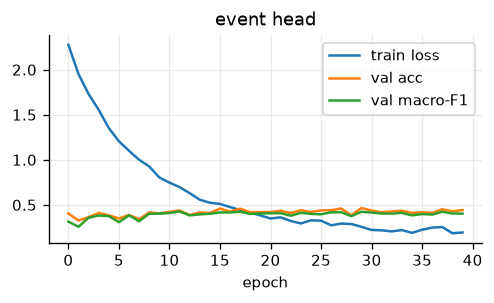

In [17]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    lk, lo, lr_ = model(val_set[0].to(DEVICE))
pk = lk.argmax(1).cpu().numpy(); yk = val_set[1].numpy()
print(classification_report(yk, pk, target_names=["none", "PUT", "TAKE"], digits=3, zero_division=0))
print("confusion (rows=true):\n", confusion_matrix(yk, pk))

ev_mask = yk > 0
yo_v, yr_v = val_set[2].numpy(), val_set[3].numpy()
print(f"\nobject top-1 on event windows     : "
      f"{(lo.argmax(1).cpu().numpy()[ev_mask] == yo_v[ev_mask]).mean():.3f}"
      f"   (chance {1/(N_OBJ+1):.3f})")

# Most PUTs name no receptacle, so they all carry the 'other' label -- a model that
# always predicts 'other' already scores the majority rate. Report both, and the
# accuracy restricted to PUTs that actually name a receptacle, which is the number
# that matters for answering "where is it".
put_mask  = yk == 1
named     = put_mask & (yr_v < N_REC)
pr        = lr_.argmax(1).cpu().numpy()
print(f"receptacle top-1 on PUT windows   : {(pr[put_mask] == yr_v[put_mask]).mean():.3f}"
      f"   (majority-class rate {(yr_v[put_mask] == N_REC).mean():.3f} -- inflated)")
print(f"  ... on PUTs naming a receptacle : "
      f"{(pr[named] == yr_v[named]).mean():.3f}   (n={named.sum()})")

fig, ax = plt.subplots(figsize=(4.2, 2.6))
ax.plot([h[0] for h in hist], label="train loss")
ax.plot([h[1] for h in hist], label="val acc")
ax.plot([h[2] for h in hist], label="val macro-F1")
ax.set_xlabel("epoch"); ax.legend(); ax.set_title("event head")
fig.tight_layout(); fig.savefig(RESULTS / "event_head_training.png", bbox_inches="tight"); plt.show()

## 7. Three perception arms

Running the memory systems on oracle events only tells us what a perfect eye would allow. Running
them on fully-detected events tells us what the end-to-end system does today, but confounds two
different failures. So there are three arms:

| arm | event times & objects | PUT vs TAKE | what it isolates |
|---|---|---|---|
| **oracle** | narrations | narrations | the ceiling; the memory policy alone |
| **oracle-time** | narrations | **predicted** | *can vision tell placement from removal?* — the contradiction signal itself |
| **learned** | **detected** | **predicted** | the end-to-end reality |

The middle arm is the one that answers H2 honestly: it produces a *noisy* contradiction signal, so
comparing it against the Ebbinghaus time axis is no longer circular.

In [18]:
@torch.no_grad()
def predict_kind_at(vid, frames, bs=256):
    '''Arm 2: given event times, predict PUT/TAKE/none from vision.'''
    vf = FEATS[vid]
    X = torch.tensor(np.stack([vf.window(vf.pos(f)) for f in frames]))
    out = []
    for i in range(0, len(X), bs):
        out.append(model(X[i:i+bs].to(DEVICE))[0].softmax(1).cpu().numpy())
    return np.concatenate(out)

@torch.no_grad()
def detect_events(vid, thresh=.5, min_gap_s=2., bs=256):
    '''Arm 3: slide over the whole video, threshold, non-max suppress.'''
    vf   = FEATS[vid]
    step = max(1, int(STRIDE_S * FPS_TARGET))
    cent = np.arange(K_WIN // 2, max(K_WIN // 2 + 1, vf.n - K_WIN // 2), step)
    X = torch.tensor(np.stack([vf.window(c) for c in cent]))
    P, O, R = [], [], []
    for i in range(0, len(X), bs):
        lk, lo, lr_ = model(X[i:i+bs].to(DEVICE))
        P.append(lk.softmax(1).cpu().numpy())
        O.append(lo.argmax(1).cpu().numpy()); R.append(lr_.argmax(1).cpu().numpy())
    P, O, R = np.concatenate(P), np.concatenate(O), np.concatenate(R)

    rows, gap = [], int(min_gap_s * FPS_TARGET / step)
    for kind_i, kind in [(1, "PUT"), (2, "TAKE")]:
        s = P[:, kind_i]
        order = np.argsort(-s)
        taken = np.zeros(len(s), bool)
        for j in order:
            if s[j] < thresh: break
            if taken[max(0, j-gap):j+gap+1].any(): continue
            taken[j] = True
            rows.append(dict(video_id=vid, frame=int(vf.idx[cent[j]]), kind=kind,
                             obj=int(O[j]), recep=int(R[j]), score=float(s[j])))
    return pd.DataFrame(rows)

print("inference helpers ready")

inference helpers ready


In [19]:
# --- build the three event streams over the evaluation videos ---
def oracle_stream():
    s = sel_events.copy()
    s["frame"] = s.start_frame
    s["obj_i"] = s.obj.map(lambda o: OBJ2I.get(o, N_OBJ))
    s["rec_i"] = s.recep.map(lambda r: N_REC if pd.isna(r) else REC2I.get(r, N_REC))
    return s[["video_id", "frame", "kind", "obj", "recep", "obj_i", "rec_i"]]

def oracle_time_stream():
    '''Same times and objects, but the PUT/TAKE call comes from the model.
    A window the model reads as `none` is a *missed* event -- it simply is not stored.'''
    parts = []
    for vid in FEATS:
        ev = sel_events[sel_events.video_id == vid]
        if not len(ev): continue
        p = predict_kind_at(vid, ((ev.start_frame + ev.stop_frame) // 2).values)
        pred = p.argmax(1)
        e = ev.copy()
        e["frame"] = e.start_frame
        e["kind"]  = [["none", "PUT", "TAKE"][i] for i in pred]
        e["score"] = p.max(1)
        parts.append(e[e.kind != "none"][["video_id", "frame", "kind", "obj", "recep", "score"]])
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

def learned_stream(thresh=.5):
    parts = [detect_events(v, thresh) for v in FEATS]
    s = pd.concat([p for p in parts if len(p)], ignore_index=True)
    # map class indices back to noun ids; 'other' buckets are unusable as answers
    inv_o = {i: o for o, i in OBJ2I.items()}; inv_r = {i: r for r, i in REC2I.items()}
    s["obj"]   = s.obj.map(lambda i: inv_o.get(i, -1))
    s["recep"] = s.recep.map(lambda i: inv_r.get(i, np.nan))
    return s[s.obj >= 0]

STREAMS = {}
STREAMS["oracle"]      = oracle_stream()
STREAMS["oracle-time"] = oracle_time_stream()
STREAMS["learned"]     = learned_stream()
for k, v in STREAMS.items():
    print(f"{k:12s} {len(v):6,} events  " +
          "  ".join(f"{a}={b}" for a, b in v.kind.value_counts().items()))

oracle        3,277 events  TAKE=1809  PUT=1468
oracle-time   2,894 events  TAKE=1550  PUT=1344
learned       2,442 events  TAKE=1225  PUT=1217


## 8. Stage 4 — the four memory systems

- **S0 last-occurrence** — answer with the most recent receptacle-bearing PUT. Always asserts.
  This is the MemPal / Ego4D-style baseline.
- **S1 + Ebbinghaus confidence** — same answer, confidence `exp(-Δt/S)`.
- **S2 + Ebbinghaus retention** — MemoryBank as written: events whose strength drops below a
  threshold are *forgotten*, so the evidence may no longer exist when asked.
- **S3 state-aware** — same retrieval, then scan for a TAKE of that object after the PUT. If found,
  refuse to assert a location.

Scoring: the system either **asserts** a receptacle or **abstains**. It is correct when it asserts
the right receptacle for an object that is really there, or abstains for one that is not.

In [20]:
DECAY_S = 6000.       # Ebbinghaus time constant, frames (~2 min); tuned on val below
RETAIN_TAU = .35      # S2 forgets an event once exp(-dt/S) drops under this

def index_stream(stream):
    idx = {}
    for (vid, obj), g in stream.groupby(["video_id", "obj"], sort=False):
        idx[(vid, obj)] = (g.frame.values, g.kind.values, g.recep.values)
    return idx

def run_system(qs, stream, system, decay_S=DECAY_S):
    idx = index_stream(stream)
    asserted, recep_out, conf_out = [], [], []
    for r in qs.itertuples():
        fr, kd, rc = idx.get((r.video_id, r.obj), (np.empty(0), np.empty(0), np.empty(0)))
        before = fr <= r.query_frame
        put_ok = before & (kd == "PUT") & ~pd.isna(rc)
        if not put_ok.any():
            asserted.append(False); recep_out.append(np.nan); conf_out.append(0.); continue
        j  = np.where(put_ok)[0][-1]
        dt = r.query_frame - fr[j]
        strength = math.exp(-dt / decay_S)

        if system == "S2" and strength < RETAIN_TAU:      # forgotten outright
            asserted.append(False); recep_out.append(np.nan); conf_out.append(0.); continue

        if system == "S3":
            contra = before & (fr > fr[j]) & (kd == "TAKE")
            if contra.any():
                asserted.append(False); recep_out.append(np.nan); conf_out.append(0.); continue

        asserted.append(True); recep_out.append(rc[j])
        conf_out.append(.9 if system in ("S0", "S3") else strength)

    out = qs.copy()
    out["asserted"] = asserted
    out["pred_recep"] = recep_out
    out["confidence"] = conf_out
    gt_there = out.gt_state == "AT"
    out["correct"] = np.where(out.asserted,
                              gt_there & (out.pred_recep == out.gt_recep),
                              ~gt_there)
    # an abstention because nothing was ever stored is 'unanswerable', not a skilful refusal
    out["answerable"] = out.asserted | (out.confidence > 0)
    return out

qs_eval = sub[sub.split == "test"].reset_index(drop=True)
print(f"evaluating on {len(qs_eval):,} test queries "
      f"({qs_eval.participant_id.unique().tolist()})")

evaluating on 26,260 test queries (['P04', 'P30'])


In [21]:
rows = []
for arm, stream in STREAMS.items():
    for system in ["S0", "S1", "S2", "S3"]:
        r = run_system(qs_eval, stream, system)
        conf_wrong = ((r.confidence > .8) & ~r.correct).mean()
        rows.append(dict(arm=arm, system=system,
                         accuracy=r.correct.mean(),
                         asserted=r.asserted.mean(),
                         conf_wrong=conf_wrong,
                         mean_conf=r.confidence.mean()))
        globals()[f"res_{arm}_{system}"] = r

res = pd.DataFrame(rows)
piv = res.pivot(index="system", columns="arm", values="accuracy")
print("current-state accuracy\n", piv.to_string(float_format=lambda x: f"{x:.3f}"))
print("\nconfidently-wrong rate (conf>0.8 and wrong)  <-- H4")
print(res.pivot(index="system", columns="arm", values="conf_wrong")
         .to_string(float_format=lambda x: f"{x:.3f}"))
print("\nassertion rate (how often it commits to a location)")
print(res.pivot(index="system", columns="arm", values="asserted")
         .to_string(float_format=lambda x: f"{x:.3f}"))

current-state accuracy
 arm     learned  oracle  oracle-time
system                              
S0        0.226   0.721        0.473
S1        0.226   0.721        0.473
S2        0.275   0.423        0.347
S3        0.275   0.991        0.538

confidently-wrong rate (conf>0.8 and wrong)  <-- H4
arm     learned  oracle  oracle-time
system                              
S0        0.108   0.279        0.238
S1        0.002   0.008        0.005
S2        0.002   0.008        0.005
S3        0.018   0.009        0.053

assertion rate (how often it commits to a location)
arm     learned  oracle  oracle-time
system                              
S0        0.120   1.000        0.615
S1        0.120   1.000        0.615
S2        0.015   0.213        0.110
S3        0.028   0.729        0.363


## 9. Stage 5 — H2 answered honestly

### 9(a) Decay as *retention* — what MemoryBank actually specifies

S2 forgets an event once its Ebbinghaus strength falls below a threshold. In conversational memory
that is reasonable: an old message is usually redundant with a newer one. In episodic *visual*
memory the old event is frequently the **only** record that the object was ever put anywhere.

In [22]:
a = res[res.arm == "oracle"].set_index("system")
print("oracle arm:")
print(f"  S1 (decay = confidence)  accuracy {a.loc['S1','accuracy']:.3f}   "
      f"asserts {a.loc['S1','asserted']:.3f}")
print(f"  S2 (decay = retention)   accuracy {a.loc['S2','accuracy']:.3f}   "
      f"asserts {a.loc['S2','asserted']:.3f}")
lost = a.loc['S1','asserted'] - a.loc['S2','asserted']
print(f"\n  queries that became unanswerable purely from forgetting: {lost:.1%}")
print(f"  accuracy bought in exchange: {a.loc['S2','accuracy']-a.loc['S1','accuracy']:+.3f}")

# sweep the decay constant: is there ANY setting where retention-decay pays?
sweep = []
for S in [1500, 3000, 6000, 12000, 30000, 60000]:
    r1 = run_system(qs_eval, STREAMS["oracle"], "S1", decay_S=S)
    r2 = run_system(qs_eval, STREAMS["oracle"], "S2", decay_S=S)
    sweep.append(dict(S=S, s1_acc=r1.correct.mean(), s2_acc=r2.correct.mean(),
                      s2_asserts=r2.asserted.mean()))
sweep = pd.DataFrame(sweep)
print("\ndecay-constant sweep (frames; 50fps -> 6000 = 2min)")
print(sweep.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

oracle arm:
  S1 (decay = confidence)  accuracy 0.721   asserts 1.000
  S2 (decay = retention)   accuracy 0.423   asserts 0.213

  queries that became unanswerable purely from forgetting: 78.7%
  accuracy bought in exchange: -0.297



decay-constant sweep (frames; 50fps -> 6000 = 2min)
    S  s1_acc  s2_acc  s2_asserts
 1500   0.721   0.333       0.071
 3000   0.721   0.371       0.129
 6000   0.721   0.423       0.213
12000   0.721   0.482       0.356
30000   0.721   0.576       0.635
60000   0.721   0.676       0.886


### 9(b) Decay as *confidence* — is elapsed time the right signal?

Section 3 showed elapsed time gets AUC 0.616 against a ground truth it does not participate in
building. The contradiction signal scored 1.000, but circularly — under oracle perception it *is*
the ground truth.

The `oracle-time` arm removes the circularity: the timing of events is given, but whether each one
was a placement or a removal comes from the model, so the contradiction signal is now genuinely
noisy and can be wrong. That is a fair fight against the time axis.

In [23]:
from sklearn.metrics import roc_auc_score

def staleness_signals(stream):
    idx = index_stream(stream)
    dts, contras = [], []
    for r in qs_eval.itertuples():
        fr, kd, rc = idx.get((r.video_id, r.obj), (np.empty(0), np.empty(0), np.empty(0)))
        before = fr <= r.query_frame
        put_ok = before & (kd == "PUT") & ~pd.isna(rc)
        if not put_ok.any():
            dts.append(np.nan); contras.append(np.nan); continue
        j = np.where(put_ok)[0][-1]
        dts.append(r.query_frame - fr[j])
        contras.append(int((before & (fr > fr[j]) & (kd == "TAKE")).sum()))
    return np.array(dts, float), np.array(contras, float)

y_all = (~qs_eval.s0_correct).astype(int).values
print(f"{'arm':<12} {'AUC time':>9} {'AUC contradiction':>19}")
for arm in ["oracle", "oracle-time", "learned"]:
    dt, ct = staleness_signals(STREAMS[arm])
    m = ~np.isnan(dt)
    if m.sum() < 100 or len(np.unique(y_all[m])) < 2:
        print(f"{arm:<12} {'--':>9} {'--':>19}"); continue
    at = roc_auc_score(y_all[m], dt[m])
    ac = roc_auc_score(y_all[m], ct[m])
    note = "  <- circular" if arm == "oracle" else f"  (covers {m.mean():.0%} of queries)"
    print(f"{arm:<12} {at:9.3f} {ac:19.3f}{note}")

arm           AUC time   AUC contradiction


oracle           0.561               0.984  <- circular


oracle-time      0.558               0.747  (covers 61% of queries)


learned          0.508               0.534  (covers 12% of queries)


calibration on the 'oracle-time' arm
(ECE over asserted answers only -- an abstention makes no claim, so it has no
 confidence to calibrate; scoring abstentions as 'confidence 0, correct' would
 hand S3 a free perfectly-calibrated bin.)

  S0  ECE 0.288   confidently-wrong 23.8%   acc 0.473   (asserted 61.5%)
  S1  ECE 0.462   confidently-wrong 0.5%   acc 0.473   (asserted 61.5%)
  S2  ECE 0.171   confidently-wrong 0.5%   acc 0.347   (asserted 11.0%)
  S3  ECE 0.046   confidently-wrong 5.3%   acc 0.538   (asserted 36.3%)


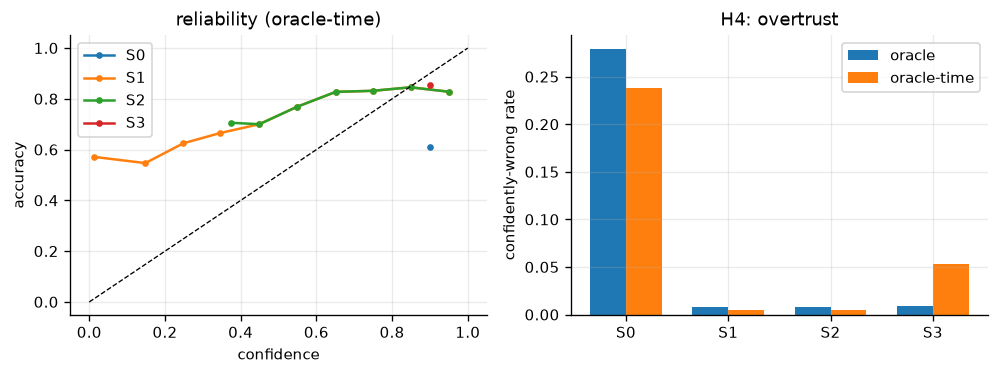

In [24]:
# --- calibration: ECE + reliability, per system, on the most realistic arm available ---
def ece(conf, correct, bins=10):
    e, n = 0., len(conf)
    edges = np.linspace(0, 1, bins + 1)
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if not m.any(): rows.append((np.nan, np.nan, 0)); continue
        acc, cf = correct[m].mean(), conf[m].mean()
        e += m.mean() * abs(acc - cf)
        rows.append((cf, acc, int(m.sum())))
    return e, rows

ARM = "oracle-time" if len(STREAMS["oracle-time"]) else "oracle"
fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.2))
print(f"calibration on the '{ARM}' arm")
print("(ECE over asserted answers only -- an abstention makes no claim, so it has no")
print(" confidence to calibrate; scoring abstentions as 'confidence 0, correct' would")
print(" hand S3 a free perfectly-calibrated bin.)\n")
for system in ["S0", "S1", "S2", "S3"]:
    r = globals()[f"res_{ARM}_{system}"]
    a = r[r.asserted]
    e, rows = ece(a.confidence.values, a.correct.values)
    cw = ((r.confidence > .8) & ~r.correct).mean()
    print(f"  {system}  ECE {e:.3f}   confidently-wrong {cw:.1%}   "
          f"acc {r.correct.mean():.3f}   (asserted {r.asserted.mean():.1%})")
    xs = [x for x, y, n in rows if n]; ys = [y for x, y, n in rows if n]
    ax[0].plot(xs, ys, "o-", label=system, ms=3)
ax[0].plot([0, 1], [0, 1], "k--", lw=.8); ax[0].set_xlabel("confidence")
ax[0].set_ylabel("accuracy"); ax[0].set_title(f"reliability ({ARM})"); ax[0].legend()

w = .35
xs = np.arange(4)
for i, arm in enumerate(["oracle", ARM]):
    sub_r = res[res.arm == arm].set_index("system").loc[["S0", "S1", "S2", "S3"]]
    ax[1].bar(xs + i*w, sub_r.conf_wrong, w, label=arm)
ax[1].set_xticks(xs + w/2); ax[1].set_xticklabels(["S0", "S1", "S2", "S3"])
ax[1].set_ylabel("confidently-wrong rate"); ax[1].set_title("H4: overtrust"); ax[1].legend()
fig.tight_layout(); fig.savefig(RESULTS / "calibration.png", bbox_inches="tight"); plt.show()

## 10. Stage 6 — H3, what does it cost to store?

The event head's `keep` score is `1 - P(none)`: how much this moment looks like a state transition.
Thresholding it gives interaction-triggered capture. The baseline is uniform sampling — keep every
n-th window — at a matched storage budget.

A placement is *retained* if some kept window lands within ±1 s of it.

In [25]:
@torch.no_grad()
def keep_scores(vid, bs=256):
    vf   = FEATS[vid]
    step = max(1, int(STRIDE_S * FPS_TARGET))
    cent = np.arange(K_WIN // 2, max(K_WIN // 2 + 1, vf.n - K_WIN // 2), step)
    X = torch.tensor(np.stack([vf.window(c) for c in cent]))
    P = []
    for i in range(0, len(X), bs):
        P.append(model(X[i:i+bs].to(DEVICE))[0].softmax(1).cpu().numpy())
    P = np.concatenate(P)
    return cent, vf.idx[cent], 1. - P[:, 0]

TEST_VIDS = [v for v in FEATS if P2SPLIT[v.split("_")[0]] == "test"]
BUDGETS = [.01, .02, .05, .10, .20, .30, .50]

# Budget is set by *rank*, not by thresholding the score. Thresholding conflates two
# things -- how good the ranking is, and where the scores happen to pile up -- and with
# this head the threshold never drives the budget below ~40%, so the low-budget regime
# the hypothesis is actually about never gets tested.
budget_rows = []
for vid in TEST_VIDS:
    cent, frames, keep = keep_scores(vid)
    puts  = sel_events[(sel_events.video_id == vid) & (sel_events.kind == "PUT")]
    put_f = ((puts.start_frame + puts.stop_frame) // 2).values
    tol   = FEATS[vid].fps * 1.0                    # +-1s, in original frames
    if not len(put_f): continue
    order = np.argsort(-keep)
    for b in BUDGETS:
        n = max(1, int(round(b * len(frames))))
        trig = frames[np.sort(order[:n])]
        uni  = frames[np.linspace(0, len(frames) - 1, n).astype(int)]
        budget_rows.append(dict(
            video_id=vid, budget=b,
            recall_triggered=np.mean([np.abs(trig - f).min() <= tol for f in put_f]),
            recall_uniform=np.mean([np.abs(uni - f).min() <= tol for f in put_f])))
budget = pd.DataFrame(budget_rows).groupby("budget").mean(numeric_only=True).reset_index()
print("placement-event recall at matched storage budget\n")
print(budget.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("\nwin/loss vs uniform at each budget:")
for r in budget.itertuples():
    d = r.recall_triggered - r.recall_uniform
    print(f"  {r.budget:5.0%}  {d:+.3f}  {'triggered wins' if d > 0 else 'uniform wins'}")

placement-event recall at matched storage budget

 budget  recall_triggered  recall_uniform
  0.010             0.039           0.021
  0.020             0.064           0.037
  0.050             0.139           0.101
  0.100             0.242           0.199
  0.200             0.413           0.387
  0.300             0.543           0.552
  0.500             0.776           0.990

win/loss vs uniform at each budget:
     1%  +0.018  triggered wins
     2%  +0.027  triggered wins
     5%  +0.038  triggered wins
    10%  +0.043  triggered wins
    20%  +0.026  triggered wins
    30%  -0.009  uniform wins
    50%  -0.214  uniform wins


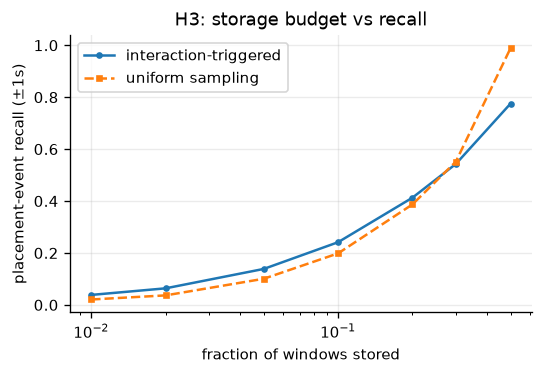

 triggered: never reaches 80% at any budget tested
   uniform: 50% of windows for 80% placement recall


In [26]:
fig, ax = plt.subplots(figsize=(4.6, 3.2))
ax.plot(budget.budget, budget.recall_triggered, "o-", ms=3, label="interaction-triggered")
ax.plot(budget.budget, budget.recall_uniform,  "s--", ms=3, label="uniform sampling")
ax.set_xscale("log"); ax.set_xlabel("fraction of windows stored")
ax.set_ylabel("placement-event recall (±1s)")
ax.set_title("H3: storage budget vs recall"); ax.legend()
fig.tight_layout(); fig.savefig(RESULTS / "h3_storage_budget.png", bbox_inches="tight"); plt.show()

for col, name in [("recall_triggered", "triggered"), ("recall_uniform", "uniform")]:
    ok = budget[budget[col] >= .8]
    print(f"{name:>10}: " + (f"{ok.budget.min():.0%} of windows for 80% placement recall"
                             if len(ok) else "never reaches 80% at any budget tested"))

### 10.1 Why uniform sampling is such a strong baseline here

Worth being clear about what this comparison can and cannot show. Recall is scored with a **±1 s
tolerance**, so retaining an event is a *coverage* problem: a kept window counts if it lands anywhere
within a second of the placement. Uniform sampling is near-optimal for coverage by construction —
evenly spaced points minimise the largest gap. For a learned selector to win it must not merely rank
placements highly, it must beat an even spacing of the timeline, which only pays off once the budget
is small enough that uniform sampling starts leaving gaps wider than the tolerance.

So this is a fair test of the hypothesis as stated, but a demanding one, and a negative result here
means "the keep score is not sharp enough to beat even spacing", not "interaction-triggered capture
cannot work".

## 10.2 Seed robustness

The oracle arm has no trained component, so it returns the same numbers every run. Everything
touching the event head does not: across two unseeded runs the `oracle-time` S3 accuracy moved from
0.545 to 0.440. With a head this weak, a single seed is not a measurement. The learned-perception
results are therefore reported as **mean ± sd over 3 seeds**, and the oracle results as exact.

In [27]:
def one_seed(s):
    set_seed(s)
    m = EventHead().to(DEVICE)
    Xtr, ktr, otr, rtr = [t.to(DEVICE) for t in train_set]
    Xva, kva = train_set and val_set[0].to(DEVICE), val_set[1].to(DEVICE)
    opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=.01)
    cnt = torch.bincount(ktr, minlength=3).float()
    w = (cnt.sum() / (3 * cnt.clamp(min=1))).to(DEVICE)
    best, best_state = -1., None
    for ep in range(40):
        m.train()
        perm = torch.randperm(len(Xtr), device=DEVICE)
        for i in range(0, len(perm), 64):
            b = perm[i:i+64]
            lk, lo, lr_ = m(Xtr[b]); msk = ktr[b] > 0
            loss = F.cross_entropy(lk, ktr[b], weight=w)
            if msk.any():
                loss = loss + .3 * F.cross_entropy(lo[msk], otr[b][msk]) \
                            + .3 * F.cross_entropy(lr_[msk], rtr[b][msk])
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad(): pk = m(Xva)[0].argmax(1).cpu().numpy()
        f1 = macro_f1(pk, kva.cpu().numpy())
        if f1 > best: best, best_state = f1, {k: v.clone() for k, v in m.state_dict().items()}
    m.load_state_dict(best_state)

    global model
    keep_model, model = model, m            # the stream builders read the global `model`
    st = oracle_time_stream()
    r0, r3 = run_system(qs_eval, st, "S0"), run_system(qs_eval, st, "S3")
    dt, ct = staleness_signals(st)
    msk = ~np.isnan(dt)
    a3 = r3[r3.asserted]
    out = dict(
        macro_f1=best,
        s0_acc=r0.correct.mean(), s3_acc=r3.correct.mean(),
        s0_confwrong=((r0.confidence > .8) & ~r0.correct).mean(),
        s3_confwrong=((r3.confidence > .8) & ~r3.correct).mean(),
        s3_ece=ece(a3.confidence.values, a3.correct.values)[0],
        auc_time=roc_auc_score(y_all[msk], dt[msk]) if msk.sum() > 100 else np.nan,
        auc_contra=roc_auc_score(y_all[msk], ct[msk]) if msk.sum() > 100 else np.nan,
        coverage=msk.mean())
    model = keep_model
    return out

seed_runs = pd.DataFrame([one_seed(s) for s in [0, 1, 2]])
print("oracle-time arm, 3 seeds\n")
for c in seed_runs.columns:
    print(f"  {c:<14} {seed_runs[c].mean():.3f} +/- {seed_runs[c].std():.3f}")
seed_runs.to_csv(RESULTS / "seed_runs.csv", index=False)

/var/folders/dt/_jymhl_n7k7by5rpm7pmf4s80000gn/T/ipykernel_6895/3508380917.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc  = nn.TransformerEncoder(enc, layers)


/var/folders/dt/_jymhl_n7k7by5rpm7pmf4s80000gn/T/ipykernel_6895/3508380917.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc  = nn.TransformerEncoder(enc, layers)


/var/folders/dt/_jymhl_n7k7by5rpm7pmf4s80000gn/T/ipykernel_6895/3508380917.py:9: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.enc  = nn.TransformerEncoder(enc, layers)


oracle-time arm, 3 seeds

  macro_f1       0.437 +/- 0.008
  s0_acc         0.444 +/- 0.046
  s3_acc         0.493 +/- 0.056
  s0_confwrong   0.227 +/- 0.044
  s3_confwrong   0.052 +/- 0.002
  s3_ece         0.070 +/- 0.036
  auc_time       0.547 +/- 0.029
  auc_contra     0.703 +/- 0.044
  coverage       0.544 +/- 0.065


## 11. Sensitivity — is H1 an artefact of how I built the labels?

The staleness number rests on four judgement calls in the query construction. Each is defensible and
each is arguable, so each gets varied. If the headline moves a lot under a reasonable alternative,
the finding is fragile and should be reported as such.

In [28]:
def variant_stale(take_verbs, recep_pick="first", cap_s=None, fps=50.):
    rows = []
    for r in ann.itertuples():
        if   r.verb_class in PUT_VERBS:  kind = "PUT"
        elif r.verb_class in take_verbs: kind = "TAKE"
        else: continue
        others = [nc for nc in r.all_noun_classes if nc != r.noun_class]
        recep = None if not others else (others[0] if recep_pick == "first" else others[-1])
        rows.append((r.video_id, r.start_frame, kind, r.noun_class, recep))
    ev = pd.DataFrame(rows, columns=["video_id", "start_frame", "kind", "obj", "recep"]) \
           .sort_values(["video_id", "start_frame"])

    ok = []
    for vid, g in ev.groupby("video_id", sort=False):
        state, last_put, last_q = {}, {}, {}
        for e in g.itertuples():
            if e.kind == "PUT":
                if not pd.isna(e.recep):
                    state[e.obj] = ("AT", e.recep); last_put[e.obj] = (e.recep, e.start_frame)
                else:
                    state[e.obj] = ("PLACED_UNKNOWN", None)
            else:
                state[e.obj] = ("GONE", None)
            for obj, (rc, pf) in last_put.items():
                if obj == e.obj and pf == e.start_frame: continue
                if cap_s is not None:
                    prev = last_q.get(obj)
                    if prev is not None and (e.start_frame - prev) < cap_s * fps: continue
                    last_q[obj] = e.start_frame
                st, gt = state[obj]
                ok.append(st == "AT" and gt == rc)
    ok = np.array(ok)
    return len(ok), 1 - ok.mean()

TAKE_STRICT = {0, 12}   # take, remove -- 'move' no longer counts as invalidating
print(f"{'variant':<34}{'queries':>10}{'stale':>9}")
print("-" * 53)
for name, tv, rp, cap in [
        ("baseline (as reported)",        TAKE_VERBS,  "first", None),
        ("'move' NOT an invalidation",    TAKE_STRICT, "first", None),
        ("receptacle = LAST other noun",  TAKE_VERBS,  "last",  None),
        ("1 query / object / 60s",        TAKE_VERBS,  "first", 60),
        ("strictest: no-move + 60s cap",  TAKE_STRICT, "first", 60)]:
    n, s = variant_stale(tv, rp, cap)
    print(f"{name:<34}{n:>10,}{s:>8.1%}")

variant                              queries    stale
-----------------------------------------------------


baseline (as reported)               173,624   30.9%


'move' NOT an invalidation           164,373   28.8%


receptacle = LAST other noun         173,624   30.9%


1 query / object / 60s                22,718   28.7%


strictest: no-move + 60s cap          22,552   27.0%


## 11. Summary

Written up with the numbers in `results/results.md`. The short version of what this notebook is for:

a system can retrieve the correct past event every single time and still be wrong about the present
in a third of cases, and no metric in the episodic-retrieval literature would show it.